<a href="https://colab.research.google.com/github/SiddharthVESIT/SEM6/blob/lab8/mldl_lab_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Build a Convolutional Neural Network (CNN) to classify handwritten digits using the MNIST dataset. The process should include loading and normalizing the data, defining an architecture with convolutional and dense layers, training the model using the Adam optimizer, and evaluating its performance through accuracy metrics and visualizations of the training history and sample predictions.

## Load and Preprocess MNIST Dataset

### Subtask:
Download the MNIST dataset, normalize pixel values, and reshape the data for CNN input.


**Reasoning**:
I will import the MNIST dataset, normalize the pixel values, reshape the images for a CNN, and verify the shapes.



In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np

# 1. Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 3. Reshape the input data to include a channel dimension (28, 28, 1)
x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

# 4. Print shapes and sample labels to verify
print(f'Training data shape: {x_train.shape}')
print(f'Testing data shape: {x_test.shape}')
print(f'First 5 training labels: {y_train[:5]}')
print('MNIST dataset loaded and preprocessed successfully.')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)
First 5 training labels: [5 0 4 1 9]
MNIST dataset loaded and preprocessed successfully.


## Define CNN Architecture

### Subtask:
Construct a Sequential model with Convolutional, Pooling, and Dense layers for handwritten digit classification.


**Reasoning**:
I will define the CNN architecture using a Sequential model with the specified convolutional, pooling, and dense layers and display the model summary.



In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

# 1. Instantiate a Sequential model using an Input layer to avoid warnings
model = Sequential([
    # 2. Explicitly define the input shape
    Input(shape=(28, 28, 1)),

    # 3. Add first Conv2D and MaxPooling2D layers
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # 4. Add second Conv2D and MaxPooling2D layers
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # 5. Flatten the 2D feature maps to a 1D vector
    Flatten(),

    # 6. Add a Dense hidden layer
    Dense(64, activation='relu'),

    # 7. Add the final Dense output layer for 10 classes
    Dense(10, activation='softmax')
])

# 8. Print the model summary to verify the architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

## Compile and Train Model

### Subtask:
Compile the CNN model and train it on the preprocessed MNIST dataset for 5 epochs.


**Reasoning**:
I will compile the model using the Adam optimizer and sparse categorical crossentropy loss, then train it for 5 epochs with a validation split of 10% and store the training history.



In [4]:
# 1. Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 2. Train the model and store history
# Using 5 epochs, batch size of 64, and 10% validation split
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

print('Model compilation and training completed.')

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9456 - loss: 0.1810 - val_accuracy: 0.9768 - val_loss: 0.0761
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.9832 - loss: 0.0535 - val_accuracy: 0.9888 - val_loss: 0.0430
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.9878 - loss: 0.0399 - val_accuracy: 0.9902 - val_loss: 0.0374
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - accuracy: 0.9916 - loss: 0.0286 - val_accuracy: 0.9900 - val_loss: 0.0392
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - accuracy: 0.9928 - loss: 0.0228 - val_accuracy: 0.9872 - val_loss: 0.0459
Model compilation and training completed.


## Evaluate and Visualize Performance

### Subtask:
Evaluate the trained CNN on the test set and visualize the training history and sample predictions.


**Reasoning**:
I will evaluate the model's performance on the test set to determine its accuracy on unseen data. Then, I will plot the training and validation curves for both accuracy and loss to check for overfitting or convergence. Finally, I will generate predictions on the test set and visualize a few samples with their true versus predicted labels to qualitatively assess the model.

**Reasoning**:
I will now write and execute the code to evaluate the model on the test set, plot the training history for accuracy and loss, and visualize sample predictions with their true labels.



Test Loss: 0.0340
Test Accuracy: 0.9894


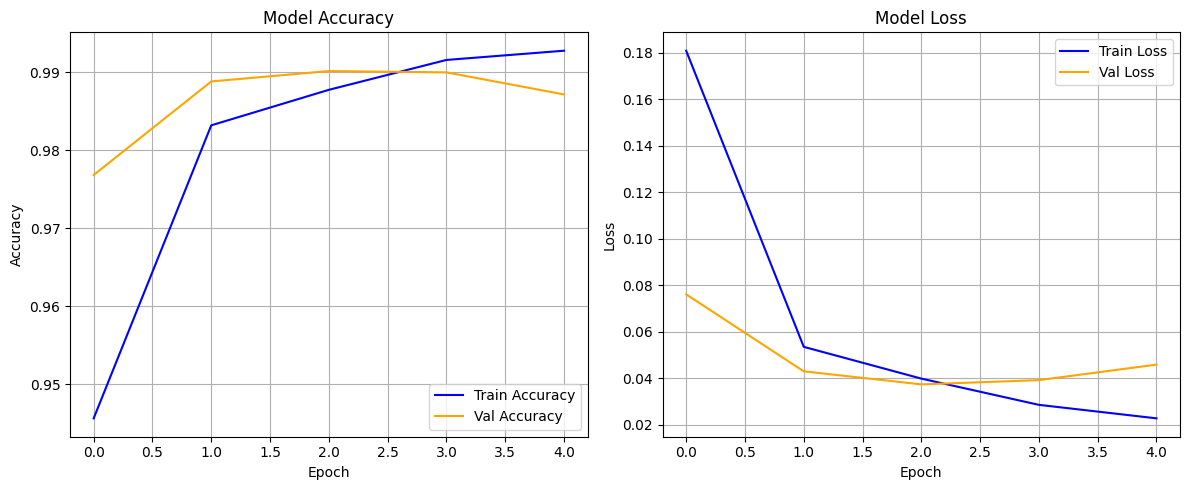

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


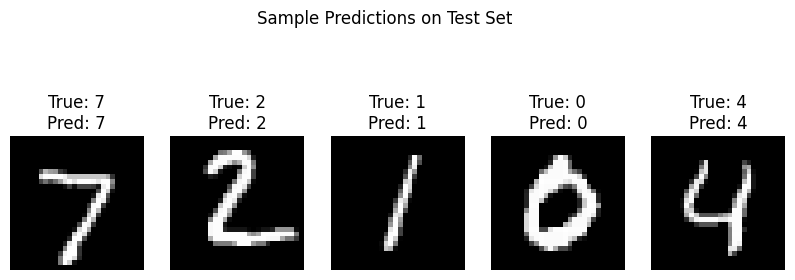

In [5]:
import matplotlib.pyplot as plt

# 1. Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

# 2. Plot Training and Validation History
plt.figure(figsize=(12, 5))

# Subplot for Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Subplot for Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 3. Generate predictions and visualize samples
predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f'True: {y_test[i]}\nPred: {predicted_labels[i]}')
    plt.axis('off')
plt.suptitle('Sample Predictions on Test Set')
plt.show()

## Final Task

### Subtask:
Summarize the model performance and the architecture used for the image classification task.


## Summary:

### Q&A

**What was the architecture used for the image classification task?**
The model utilized a Convolutional Neural Network (CNN) architecture consisting of:
*   Two **Convolutional layers** (32 and 64 filters) with $3 \times 3$ kernels and ReLU activation.
*   Two **MaxPooling2D layers** ($2 \times 2$ pool size) for spatial dimension reduction.
*   A **Flatten layer** to convert 2D features into a 1D vector.
*   A **Dense hidden layer** with 64 units and ReLU activation.
*   A **Dense output layer** with 10 units and Softmax activation for classifying the digits 0-9.

**How did the model perform on the handwritten digit classification task?**
The model demonstrated high performance, achieving a **Test Accuracy of 98.94%** and a **Test Loss of 0.0340**. Training history plots indicated steady convergence with no significant overfitting, as validation accuracy (98.72%) remained close to training accuracy (99.28%).

### Data Analysis Key Findings
*   **Dataset Preparation:** 70,000 images (60,000 training, 10,000 testing) were normalized to a \[0, 1\] range and reshaped to $(28, 28, 1)$ to include the grayscale channel required for CNN processing.
*   **Model Complexity:** The constructed CNN contains **121,930 trainable parameters**.
*   **Training Efficiency:** Within only **5 epochs** using the Adam optimizer and a batch size of 64, the training loss dropped significantly from **0.1810** to **0.0228**.
*   **Generalization:** The small gap between training accuracy ($99.28\%$) and test accuracy ($98.94\%$) confirms the model generalizes well to new, unseen data.
*   **Qualitative Success:** Sample visualizations confirmed that the model correctly predicts labels for varied handwritten styles in the test set.

### Insights or Next Steps
*   **Insight:** The high accuracy achieved in just 5 epochs suggests that CNNs are exceptionally well-suited for the spatial patterns in the MNIST dataset compared to standard fully connected networks.
*   **Next Steps:** To further improve performance or test robustness, one could implement **Data Augmentation** (rotations/shifts) or introduce **Dropout layers** to further mitigate any potential overfitting in more complex datasets.
